In [15]:
import torch
import numpy as np

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer

In [16]:
num_dim = 1
prior = utils.BoxUniform(low=0.00001*torch.ones(num_dim), high=torch.ones(num_dim))

In [17]:
def simple_relation(initial_velocity, M_sat):
    #return final velocity
    return initial_velocity + M_sat + torch.randn_like(M_sat) * 0.01


In [18]:
def simulator(M_sat):
    velocity=0.2
    return simple_relation(velocity, M_sat)

In [19]:
posterior = infer(simulator, prior, "SNPE", num_simulations=100)


Running 100 simulations.: 100%|██████████| 100/100 [00:00<00:00, 34116.67it/s]
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/sbi/neural_nets/flow.py:141: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  warn("In one-dimensional output space, this flow is limited to Gaussians")


 Neural network successfully converged after 64 epochs.

In [20]:
observation1=[0.7]
observation2=[1.2]

Drawing 100 posterior samples: 100%|██████████| 100/100 [00:00<00:00, 20197.94it/s]


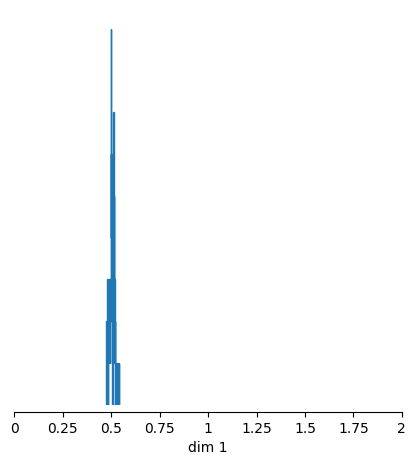

In [21]:
posterior_samples_1 = posterior.sample((100,), x=observation1)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[0,2]], figsize=(5, 5)
)


Drawing 100 posterior samples: 146it [00:00, 19317.01it/s]            


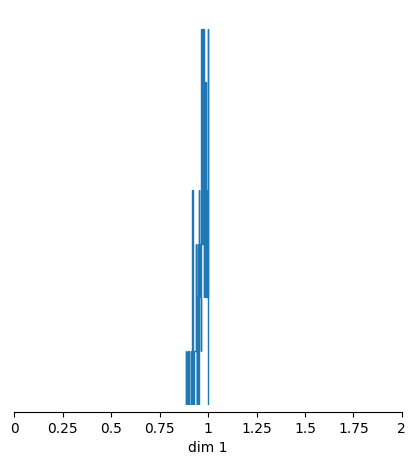

In [22]:
posterior_samples_2 = posterior.sample((100,), x=observation2)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_2, limits=[[0,2]], figsize=(5, 5)
)